In [10]:
import pandas as pd
import numpy as np
df_raw = pd.read_csv("feature-engineering.csv")

In [11]:
#nope there is no duplicates
print(f"Shape before dropping duplicates: {df_raw.shape}")
df_raw = df_raw.drop_duplicates()
print(f"Shape after dropping duplicates: {df_raw.shape}")

Shape before dropping duplicates: (235795, 49)
Shape after dropping duplicates: (235757, 49)


In [12]:
#standardize text columns
for col in [col for col in df_raw.columns if col.startswith("O")]:
    df_raw[col] = df_raw[col].str.lower().str.strip()

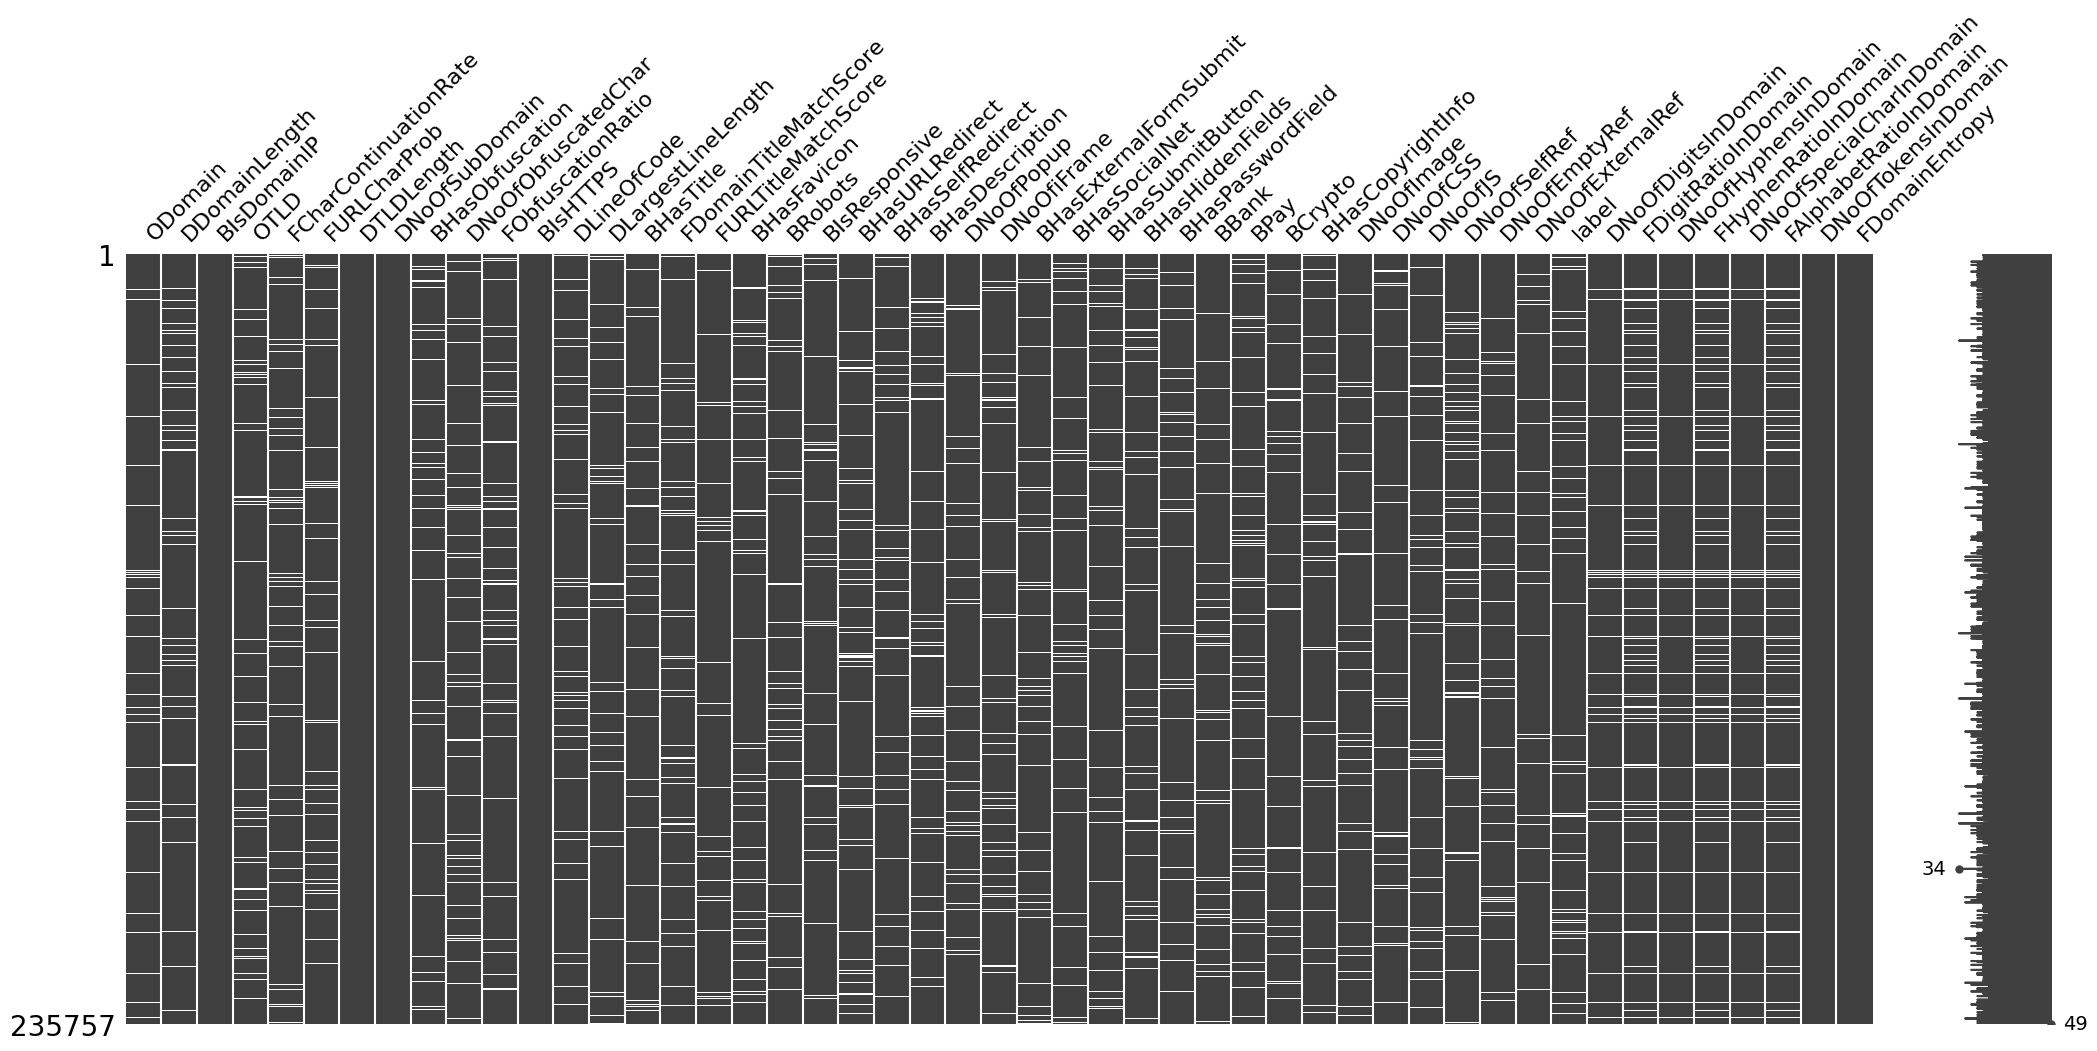

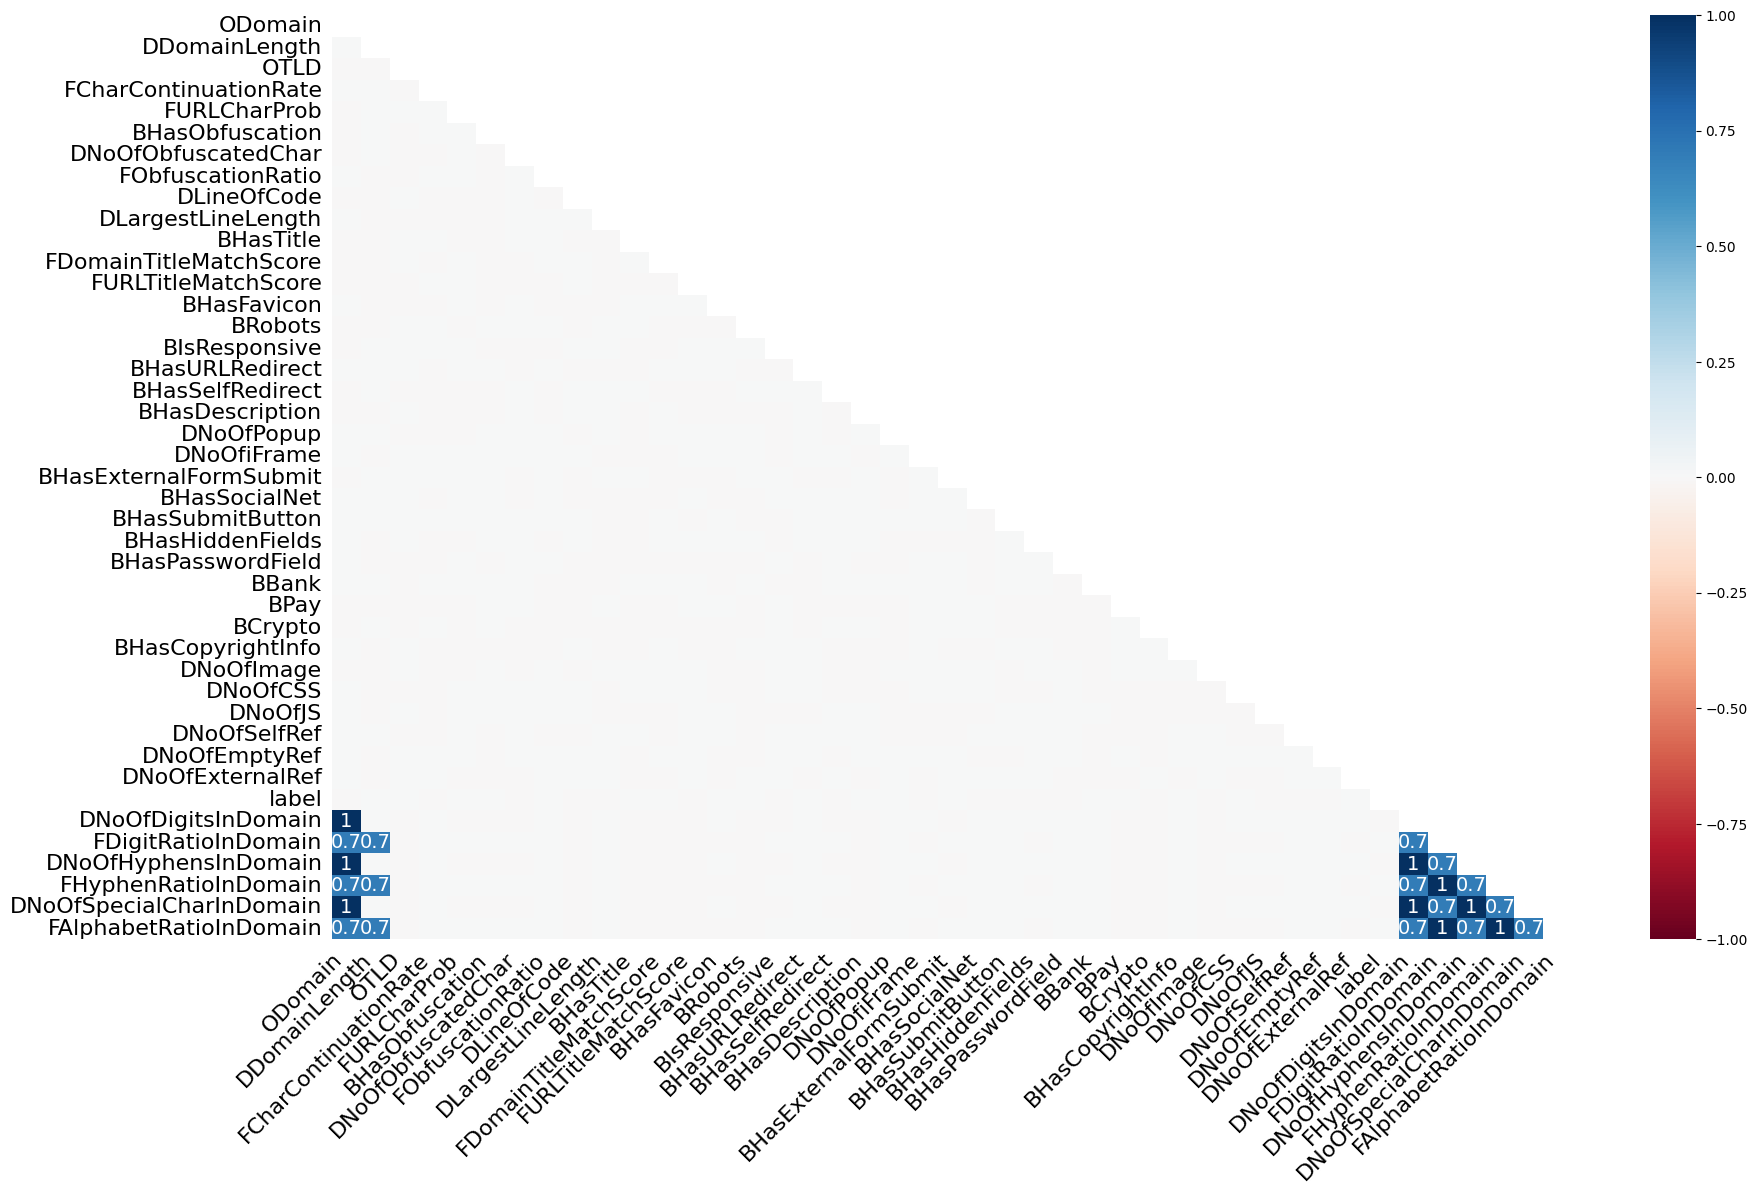

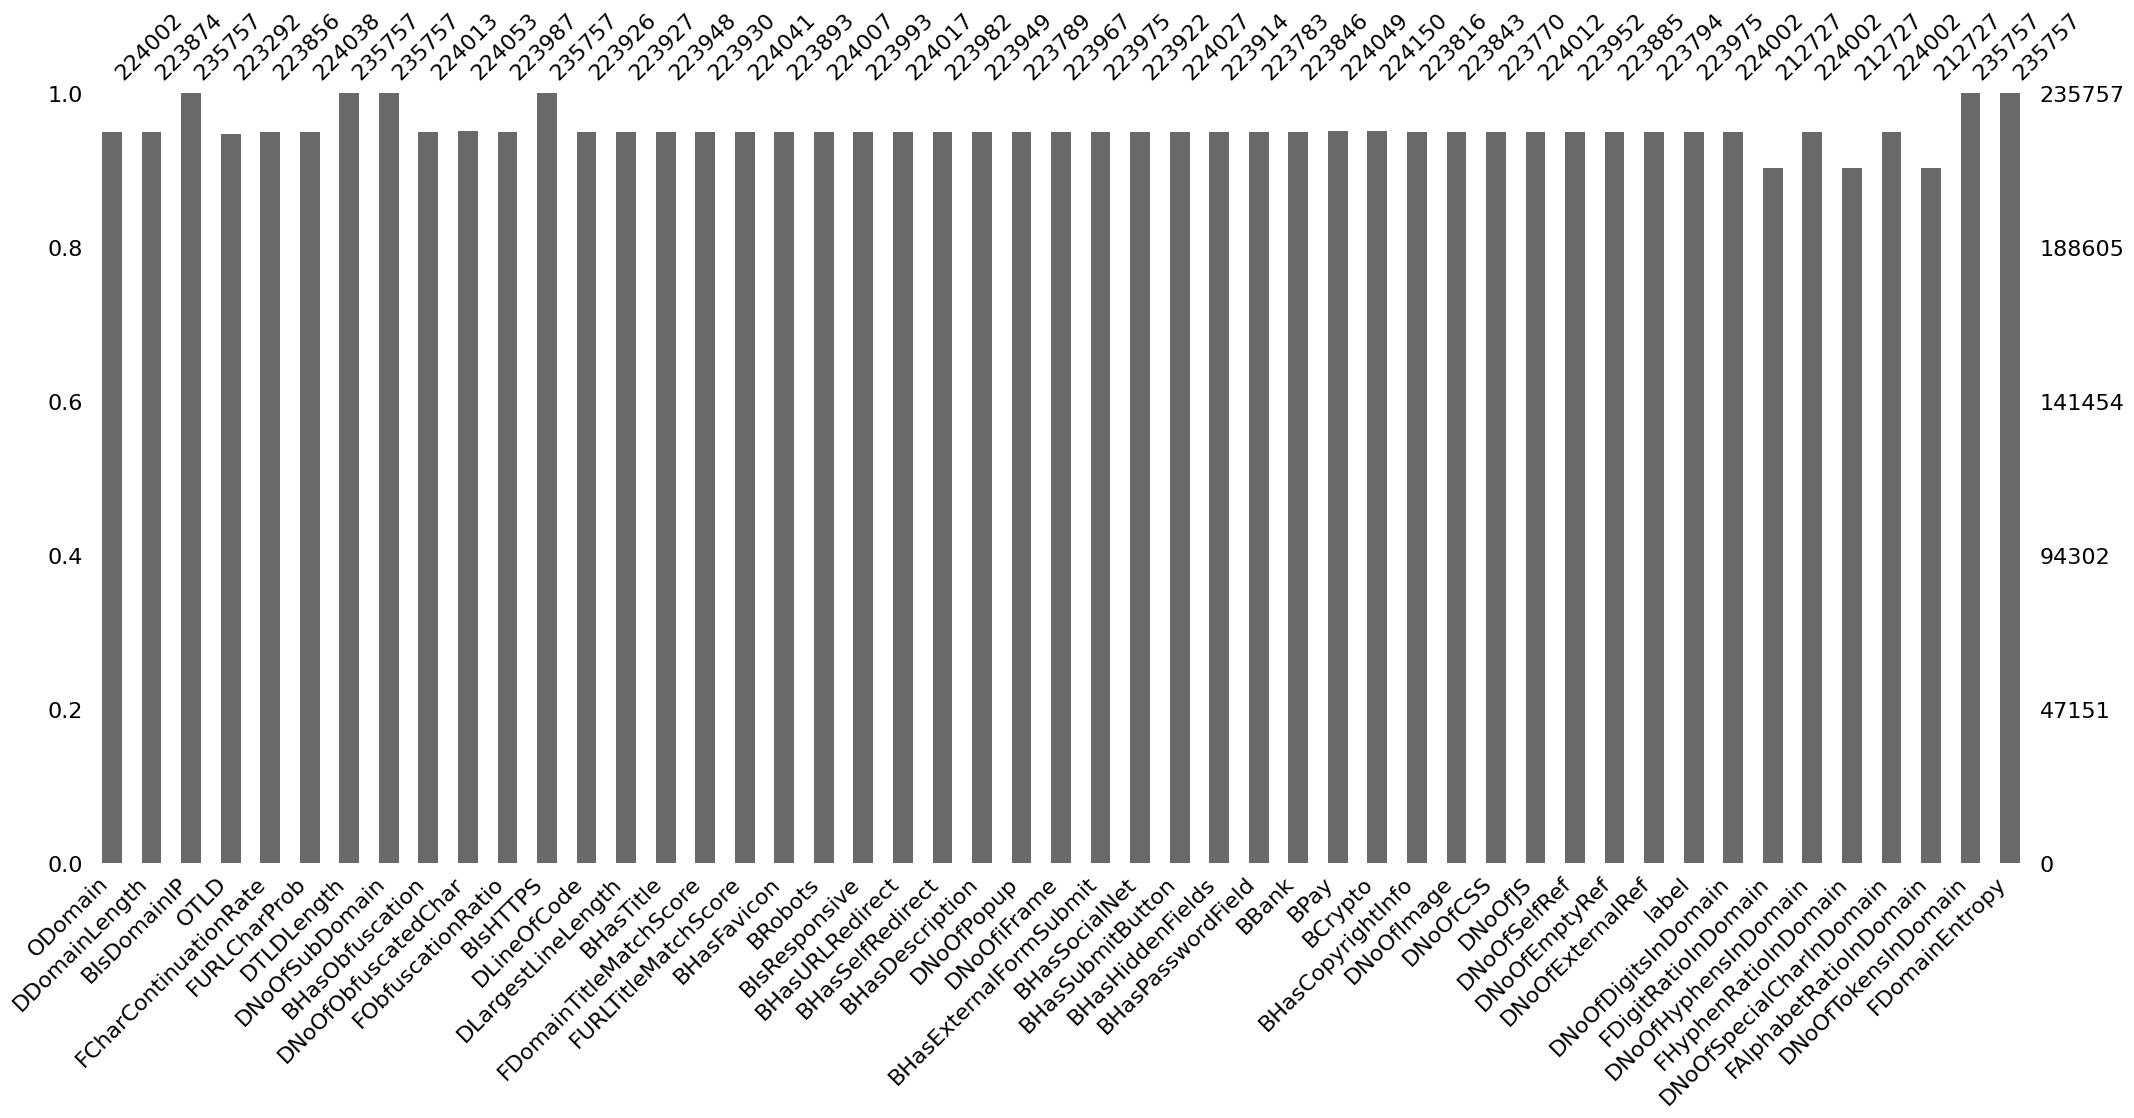

In [13]:
# I find that people use missingno library for visualizing missing data
import missingno as msno
import matplotlib.pyplot as plt
msno.matrix(df_raw)
plt.show()
msno.heatmap(df_raw)
plt.show()
msno.bar(df_raw)
plt.show()
# conclusion: The Missing Value Analysis confirms that the data are MCAR.

#bunu EDA ekle: # 2. DROP SPECIFIC COLUMNS
# Removing the "cheat" feature (URLSimilarityIndex) and the probability feature
#there are categorical columns with high cardinality, so I will drop them bc they may not contribute much to the model performance
#also TLD and TLDLegitimateProb are correlated, so dropping TLDLegitimateProb and delete URLSimilarityIndex to avoid model just relying on URL similarityindex to cheat
# errors='ignore' ensures code doesn't crash if columns are already gone

##############
DATA SPLIT VE TLDLEGITPROB, URLsimlaryindex'in drop edilmis imalancea dikkat edilerek

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer  # Required for MICE
from sklearn.impute import IterativeImputer
from category_encoders import TargetEncoder

# 1. DROP ROWS WITH MISSING LABELS
# We cannot use rows without a target for training or testing
df = df_raw.dropna(subset=['label'])

# 2. DROP SPECIFIC COLUMNS
# Removing the "cheat" feature (URLSimilarityIndex) and the probability feature
#there are categorical columns with high cardinality, so I will drop them bc they may not contribute much to the model performance
#also TLD and TLDLegitimateProb are correlated, so dropping TLDLegitimateProb and delete URLSimilarityIndex to avoid model just relying on URL similarityindex to cheat
# errors='ignore' ensures code doesn't crash if columns are already gone

# 3. STRATIFIED TRAIN-TEST SPLIT (70% Train, 30% Test)
X = df.drop(columns=['label'])
y = df['label']

# stratify=y ensures the ratio of Phishing/Legit is the same in Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y 
)
#for EDA purpose I will save X_train combine with y_train as Phishing_URL_ds_5percent_missing_train.csv
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined.to_csv('feature-engineering_train.csv', index=False)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")



Train Shape: (156782, 48), Test Shape: (67193, 48)


In [17]:
# 4. TARGET ENCODING (TLD)
tld_col = 'TLD'

if tld_col in X_train.columns:
    # We use smoothing to prevent overfitting on rare TLDs
    encoder = TargetEncoder(cols=[tld_col], smoothing=10)
    
    # CRITICAL: Fit ONLY on X_train to prevent data leakage
    X_train[tld_col] = encoder.fit_transform(X_train[tld_col], y_train)
    
    # Transform X_test using the rules learned from X_train
    X_test[tld_col] = encoder.transform(X_test[tld_col])
    print("Target Encoding applied successfully.")
#drop unneccersary columns after encoding to apply MICE
cols_to_drop = [col for col in X_train.columns if col.startswith("O")]
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')
# 5. MICE IMPUTATION
# Initializes the MICE imputer
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# CRITICAL: Fit ONLY on X_train
# MICE learns the relationships between columns in the training set
X_train_matrix = mice_imputer.fit_transform(X_train)

# Apply those relationships to fill gaps in X_test
X_test_matrix = mice_imputer.transform(X_test)

# Convert back to DataFrame (because Imputer returns Numpy Arrays)
X_train = pd.DataFrame(X_train_matrix, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_matrix, columns=X_test.columns, index=X_test.index)

print("Preprocessing complete. X_train and X_test are ready for modeling.")

Preprocessing complete. X_train and X_test are ready for modeling.


In [18]:
Train = pd.concat([X_train, y_train], axis=1)
Test = pd.concat([X_test, y_test], axis=1)

In [19]:
print(f"After the cleaning size of our df: {Train.shape}")
print(f"Total NaN number: {Train.isnull().sum().sum()}")
print(f"After the cleaning size of our df: {Test.shape}")
print(f"Total NaN number: {Test.isnull().sum().sum()}")

After the cleaning size of our df: (156782, 47)
Total NaN number: 0
After the cleaning size of our df: (67193, 47)
Total NaN number: 0


In [20]:
#fixing binary columns scaling issue bc MICE may have changed binary columns to non-binary
binary_cols = [col for col in Train.columns if col.startswith("B")]
for col in binary_cols:
    if col in Train.columns:
        # SENİN İSTEDİĞİN GARANTİ YÖNTEM (Vectorized Thresholding)
        # Değer 0.5'ten büyükse True(1) olur, değilse False(0) olur.
        # .astype(int) ile True/False'u 1/0'a çeviririz.
        Train[col] = (Train[col] > 0.5).astype(int)
for col in binary_cols:
    if col in Test.columns:
        # SENİN İSTEDİĞİN GARANTİ YÖNTEM (Vectorized Thresholding)
        # Değer 0.5'ten büyükse True(1) olur, değilse False(0) olur.
        # .astype(int) ile True/False'u 1/0'a çeviririz.
        Test[col] = (Test[col] > 0.5).astype(int)

In [21]:
print(Train[binary_cols].nunique())
print(Test[binary_cols].describe())

BIsDomainIP               2
BHasObfuscation           2
BIsHTTPS                  2
BHasTitle                 2
BHasFavicon               2
BRobots                   2
BIsResponsive             2
BHasURLRedirect           2
BHasSelfRedirect          2
BHasDescription           2
BHasExternalFormSubmit    2
BHasSocialNet             2
BHasSubmitButton          2
BHasHiddenFields          2
BHasPasswordField         2
BBank                     2
BPay                      2
BCrypto                   2
BHasCopyrightInfo         2
dtype: int64
        BIsDomainIP  BHasObfuscation      BIsHTTPS     BHasTitle  \
count  67193.000000     67193.000000  67193.000000  67193.000000   
mean       0.002530         0.001950      0.741268      0.863914   
std        0.050236         0.044112      0.437941      0.342882   
min        0.000000         0.000000      0.000000      0.000000   
25%        0.000000         0.000000      0.000000      1.000000   
50%        0.000000         0.000000      1.000

In [22]:
Train.to_csv('feature-engineering_imputed_train.csv', index=False)
Test.to_csv('feature-engineering_imputed_test.csv', index=False)